In [ ]:
pip install lightgbm shap torch scikit-learn pandas numpy matplotlib

In [ ]:
# System & File Handling
import os
import zipfile
import glob

# Data Wrangling & Math
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# Models & Explainability
import lightgbm as lgb
import shap
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
import zipfile
import pandas as pd
from google.colab import files

print("Upload cities.zip:")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, "r") as z:
    target = [f for f in z.namelist() if f.endswith("COLUMBUS_COMBINED.csv")][0]
    df_raw = pd.read_csv(z.open(target))

print("Dataset Shape:", df_raw.shape)
print(df_raw.head(3))

Upload cities.zip:


Saving cities.zip to cities.zip
Dataset Shape: (52602, 19)
  Balancing Authority   Data Date  Hour Number Sub-Region Demand (MW)  \
0                SWPP  2018-07-01            1       NPPD         NaN   
1                SWPP  2018-07-01            2       NPPD         NaN   
2                SWPP  2018-07-01            3       NPPD         NaN   

  Local Time at End of Hour UTC Time at End of Hour      CITY  Season  YEAR  \
0     07/01/2018 1:00:00 AM   07/01/2018 6:00:00 AM  COLUMBUS  Summer  2018   
1     07/01/2018 2:00:00 AM   07/01/2018 7:00:00 AM  COLUMBUS  Summer  2018   
2     07/01/2018 3:00:00 AM   07/01/2018 8:00:00 AM  COLUMBUS  Summer  2018   

   MO  DY  HR    T2M  T2MDEW  T2MWET   QV2M   RH2M  PRECTOTCORR  
0   7   1   0  20.90   18.32   19.61  13.43  85.06          0.0  
1   7   1   1  20.58   18.27   19.43  13.37  86.50          0.0  
2   7   1   2  20.34   18.29   19.31  13.37  87.88          0.0  


In [ ]:
# Identify datetime and demand columns
time_col = 'Local Time at End of Hour' if 'Local Time at End of Hour' in df_raw.columns else 'Local Time'
demand_col = [col for col in df_raw.columns if 'Demand' in col][0]

In [ ]:
# Parse timestamps and sort chronologically
df = df_raw.copy()
df['Timestamp'] = pd.to_datetime(df[time_col])
df = df.sort_values('Timestamp').drop_duplicates(subset=['Timestamp']).reset_index(drop=True)
df.set_index('Timestamp', inplace=True)

In [ ]:
# Interpolate any missing load values
df['Demand'] = df[demand_col].interpolate(method='linear')
print(f"Time-series span: from {df.index.min()} to {df.index.max()}")

Time-series span: from 2018-07-01 01:00:00 to 2024-07-01 00:00:00


/tmp/ipykernel_837/3101762856.py:2: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['Demand'] = df[demand_col].interpolate(method='linear')


In [ ]:
# Calendar features
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

In [ ]:
# Cyclical trigonometric transformations
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24.0)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24.0)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12.0)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12.0)

In [ ]:
# Autoregressive Lag Features
df['Lag_1'] = df['Demand'].shift(1)       # Previous hour
df['Lag_24'] = df['Demand'].shift(24)     # Same hour yesterday
df['Lag_168'] = df['Demand'].shift(168)   # Same hour last week

In [ ]:
# Clean and convert 'Demand' to numeric (coerces non-numeric values to NaN)
df['Demand'] = pd.to_numeric(
    df['Demand'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)

In [ ]:
# Compute rolling statistics (24-hour lookback)
df['Rolling_Mean_24'] = df['Demand'].shift(1).rolling(window=24).mean()
df['Rolling_Std_24'] = df['Demand'].shift(1).rolling(window=24).std()

In [ ]:
# Drop rows at the beginning that contain NaNs due to shifting
df.dropna(inplace=True)
print("Features created successfully. Rows remaining:", len(df))

Features created successfully. Rows remaining: 50748


In [ ]:
# Feature matrix selection
weather_features = [c for c in ['T2M', 'T2MDEW', 'T2MWET', 'QV2M', 'RH2M', 'PRECTOT'] if c in df.columns]
feature_columns = ['Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfWeek', 'IsWeekend',
                   'Lag_1', 'Lag_24', 'Lag_168', 'Rolling_Mean_24', 'Rolling_Std_24'] + weather_features

X = df[feature_columns]
y = df['Demand']

In [ ]:
# 80/20 Chronological split
split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Train samples: 40598 | Test samples: 10150


In [ ]:
# Remove commas and convert to float
X_train = X_train.replace(',', '', regex=True).astype(float)
X_test = X_test.replace(',', '', regex=True).astype(float)
y_train = y_train.replace(',', '', regex=True).astype(float)
y_test = y_test.replace(',', '', regex=True).astype(float)

In [ ]:
import lightgbm as lgb
import pandas as pd

# Convert all feature and target columns to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

# Initialize and train LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    objective="regression",
)

lgb_reg.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

# Predictions
y_pred_lgb = lgb_reg.predict(X_test)
print("LightGBM Training Completed.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002116 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2620
[LightGBM] [Info] Number of data points in the train set: 40598, number of used features: 16
[LightGBM] [Info] Start training from score 1958.628553
LightGBM Training Completed.


In [ ]:
# Scale inputs and targets
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# Sliding sequence generator (past 24 hours -> current hour)
SEQ_LEN = 24

def build_sequences(features, targets, seq_len):
    x_seq, y_seq = [], []
    for i in range(len(features) - seq_len):
        x_seq.append(features[i : i + seq_len])
        y_seq.append(targets[i + seq_len])
    return np.array(x_seq), np.array(y_seq)

X_train_seq, y_train_seq = build_sequences(X_train_scaled, y_train_scaled, SEQ_LEN)
X_test_seq, _ = build_sequences(X_test_scaled, np.zeros((len(X_test_scaled), 1)), SEQ_LEN)

# Create PyTorch DataLoaders
train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_seq, dtype=torch.float32),
    torch.tensor(y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [ ]:
class DemandLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(DemandLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Take the output of the last time-step in the sequence
        last_step = lstm_out[:, -1, :]
        out = self.fc(last_step)
        return out

# Instantiate model, optimizer, loss
lstm_model = DemandLSTM(input_size=X_train.shape[1])
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# Training loop
lstm_model.train()
for epoch in range(10):
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = lstm_model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/10 - Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/10 - Loss: 0.0264
Epoch 2/10 - Loss: 0.0105
Epoch 3/10 - Loss: 0.0103
Epoch 4/10 - Loss: 0.0095
Epoch 5/10 - Loss: 0.0094
Epoch 6/10 - Loss: 0.0093
Epoch 7/10 - Loss: 0.0090
Epoch 8/10 - Loss: 0.0090
Epoch 9/10 - Loss: 0.0086
Epoch 10/10 - Loss: 0.0083


In [ ]:
# Inference with LSTM
lstm_model.eval()
with torch.no_grad():
    y_pred_lstm_scaled = lstm_model(torch.tensor(X_test_seq, dtype=torch.float32)).numpy()

y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
y_test_lstm_true = y_test.iloc[SEQ_LEN:].values

# Metric calculation function
def get_metrics(y_true, y_pred):
    return {
        "MAE (MW)": round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE (MW)": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "MAPE (%)": round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2)
    }

# Benchmark comparison table
results_df = pd.DataFrame([
    get_metrics(y_test, y_pred_lgb),
    get_metrics(y_test_lstm_true, y_pred_lstm)
], index=["LightGBM", "LSTM (Neural Net)"])

results_df

,MAE (MW),RMSE (MW),MAPE (%)
LightGBM,46.74,2295.44,1.20
LSTM (Neural Net),57.59,2298.26,1.75


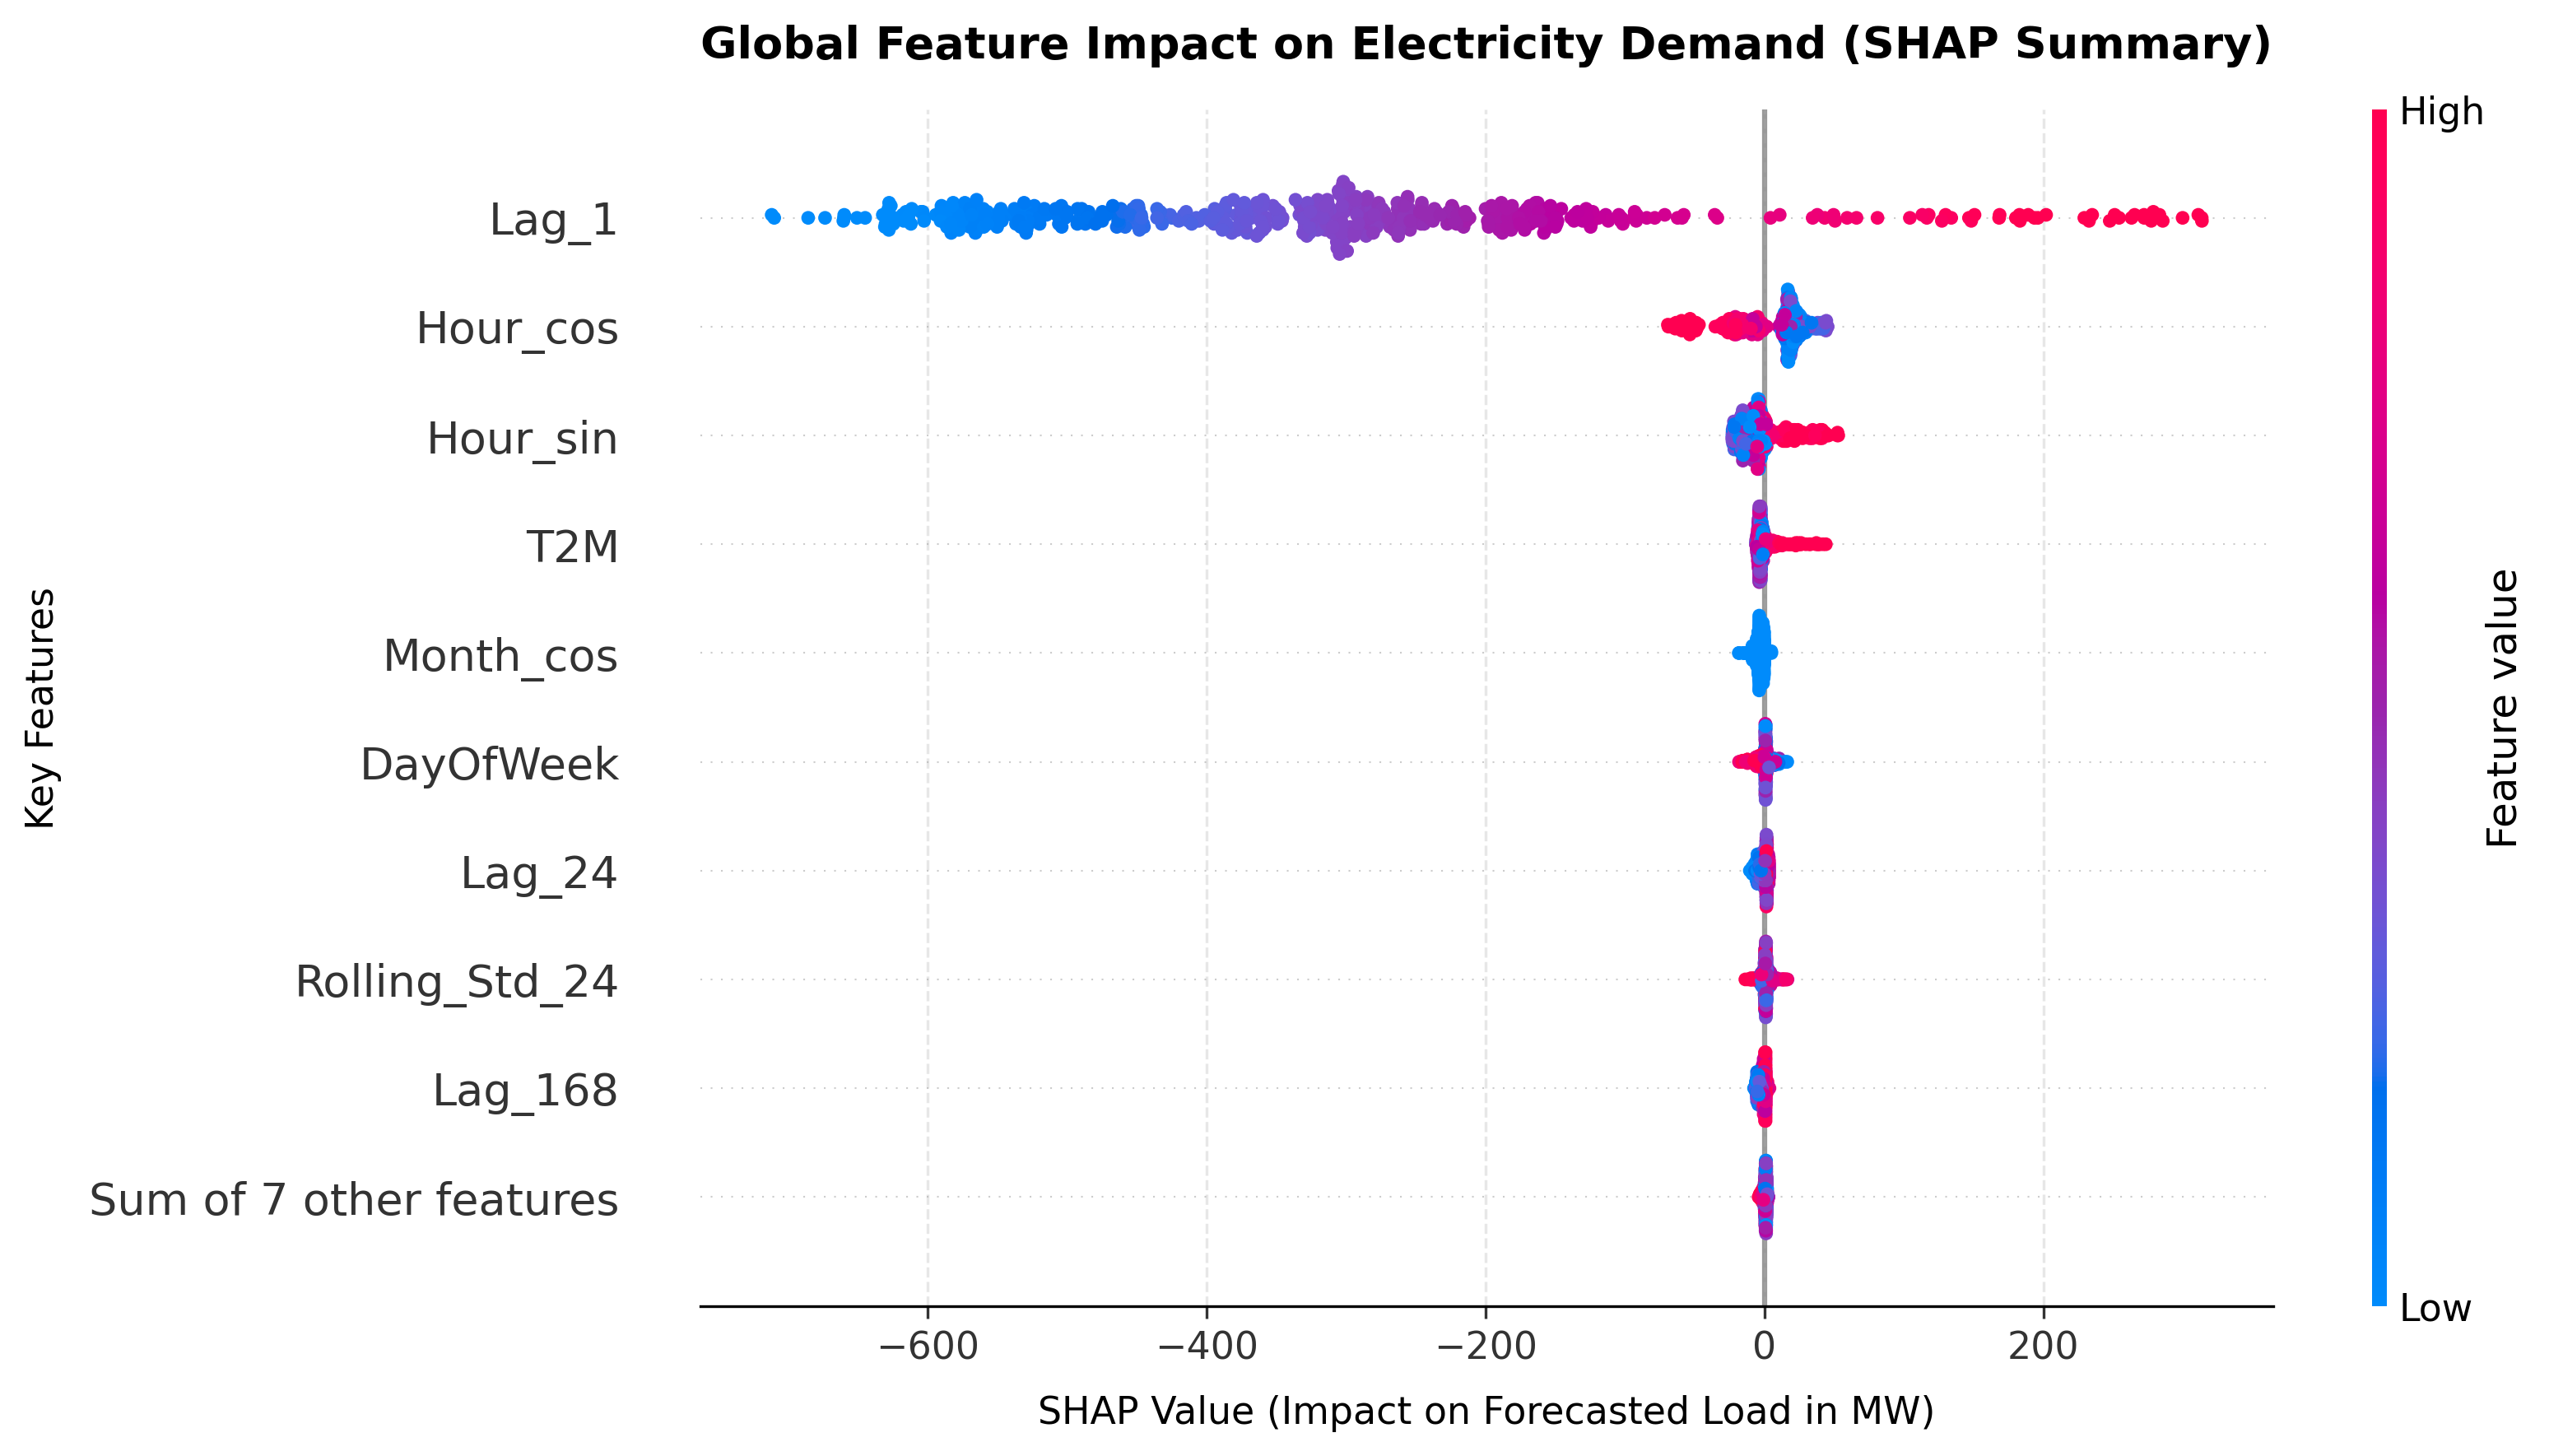

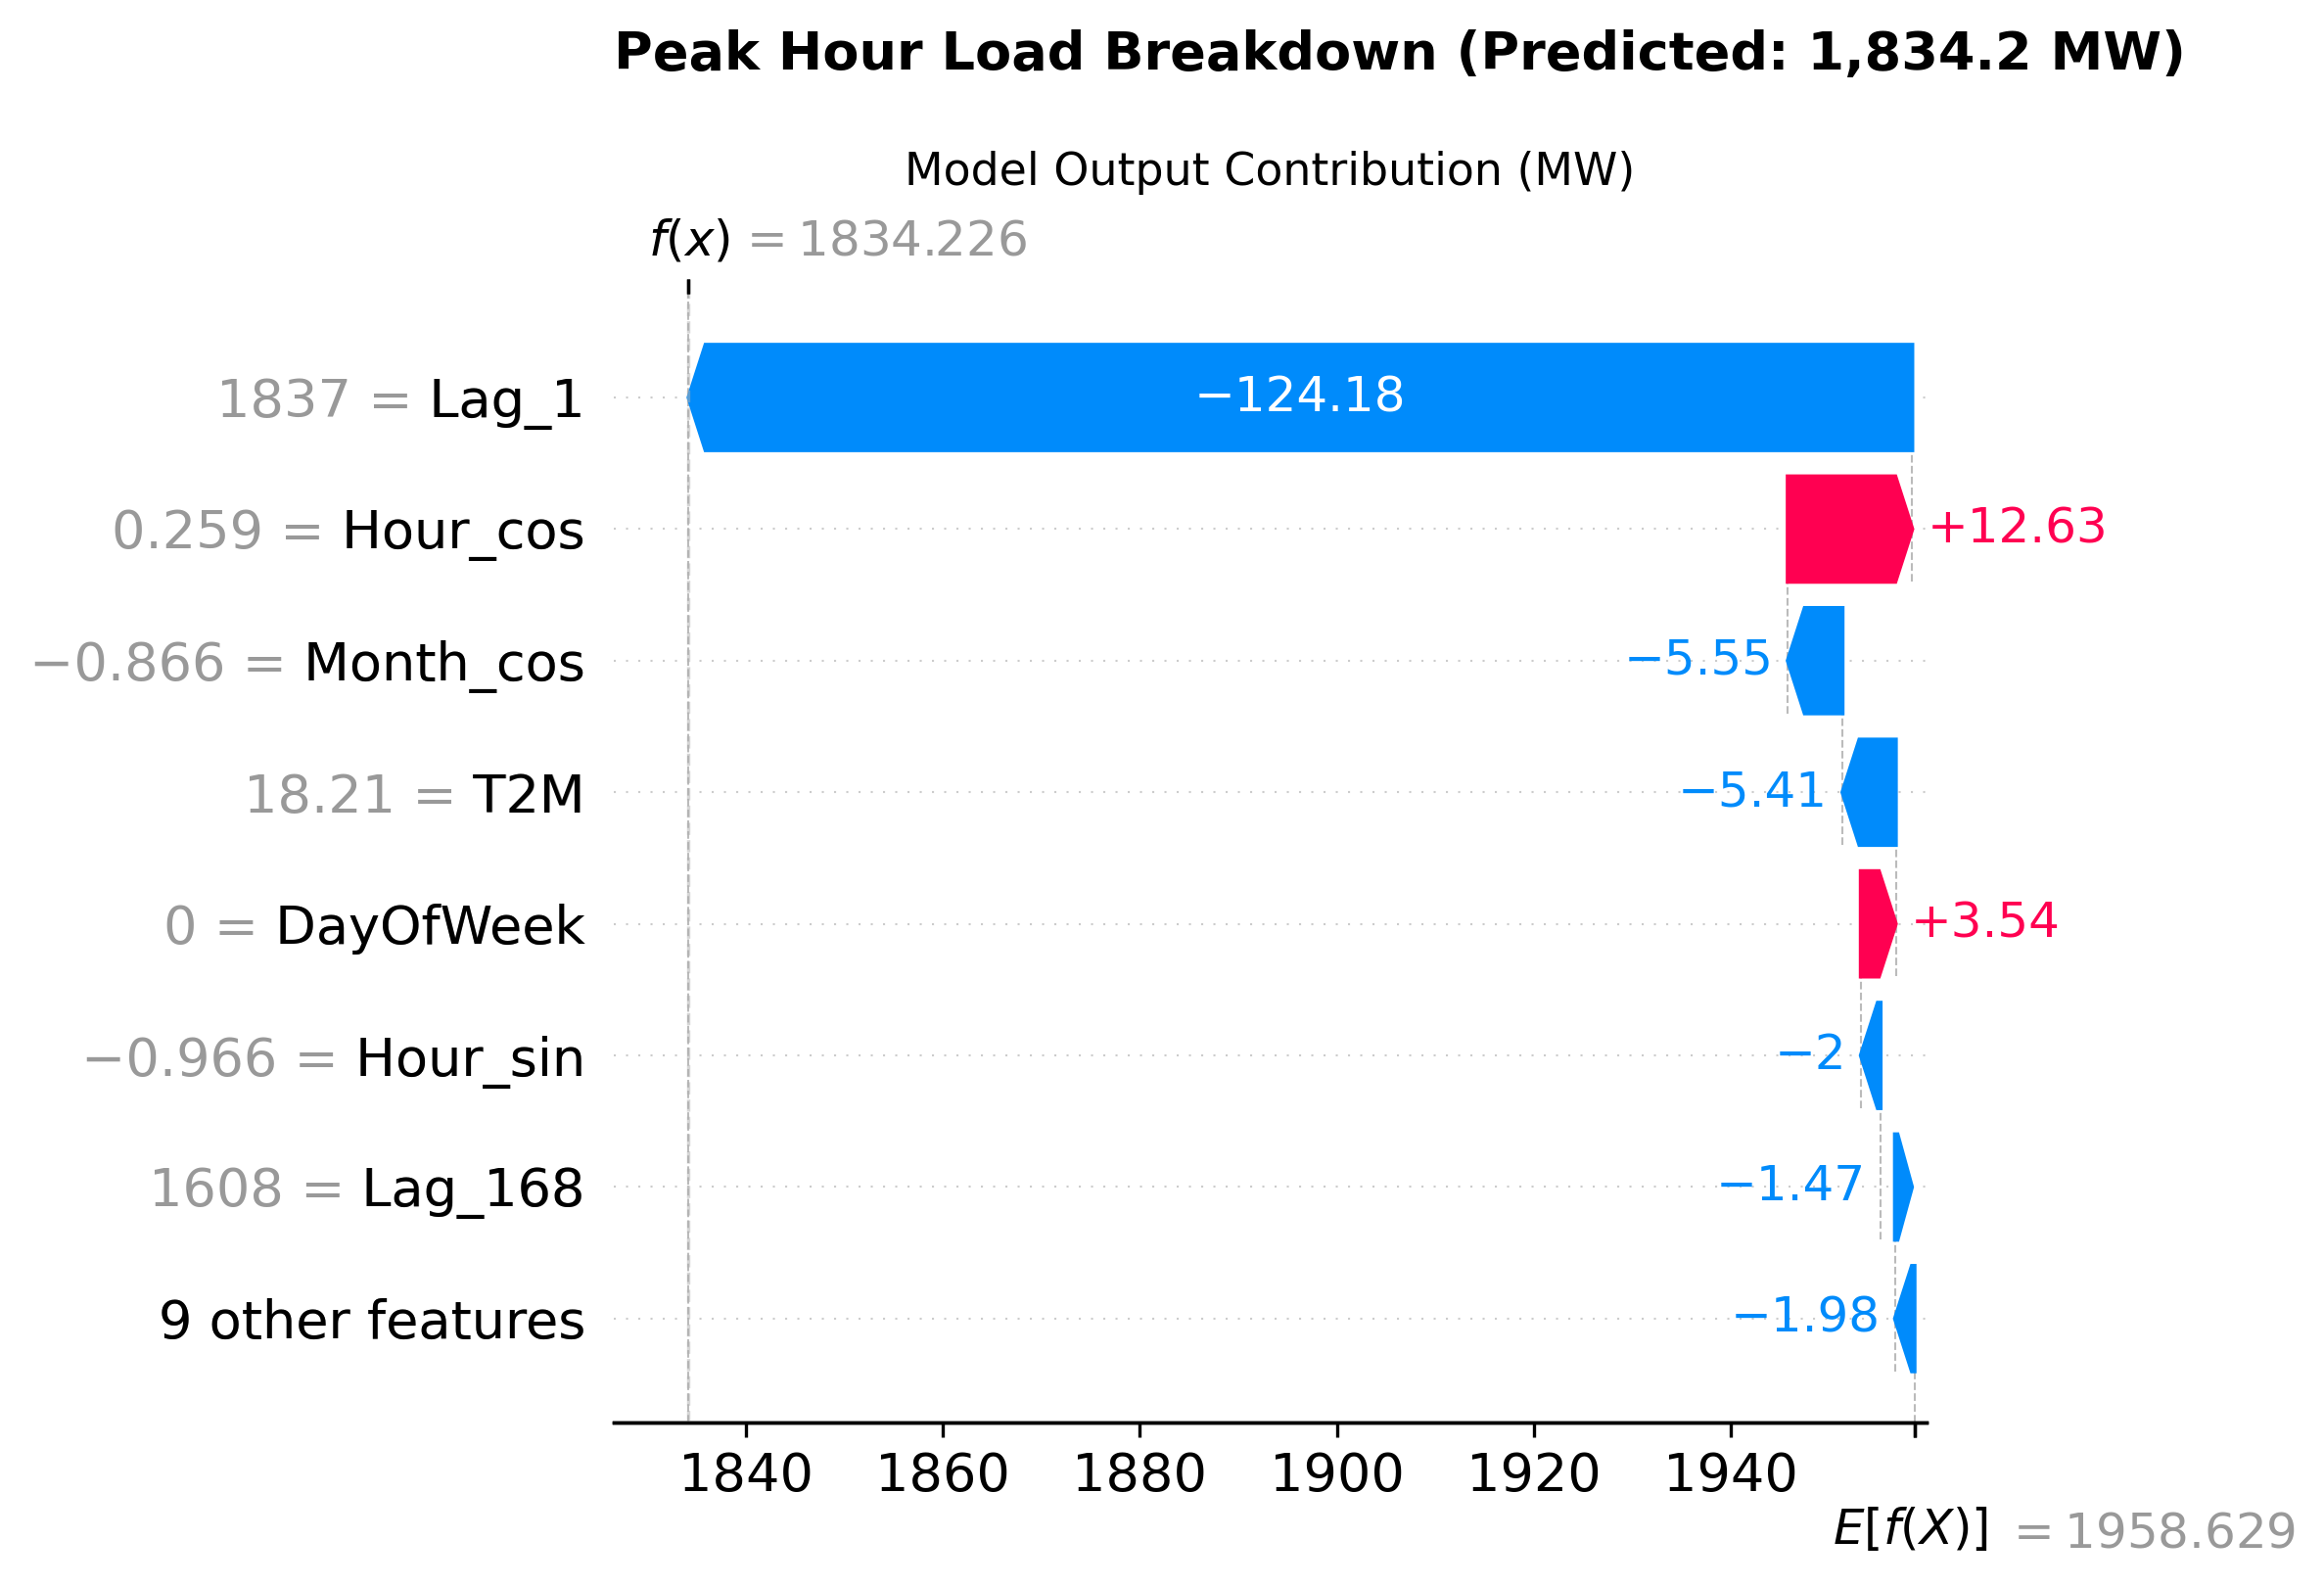

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import shap

# Configure clean aesthetic styling
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.family"] = "sans-serif"

# Compute SHAP values
explainer = shap.TreeExplainer(lgb_reg)
shap_values = explainer(X_test.iloc[:500])

# ==============================================================================
# 1. ENHANCED GLOBAL BEESWARM SUMMARY PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

# Pass show=False to customize title and axes
shap.plots.beeswarm(shap_values, max_display=10, show=False, plot_size=None)

plt.title(
    "Global Feature Impact on Electricity Demand (SHAP Summary)",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
plt.xlabel("SHAP Value (Impact on Forecasted Load in MW)", fontsize=11, labelpad=8)
plt.ylabel("Key Features", fontsize=11, labelpad=8)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 2. ENHANCED LOCAL PEAK HOUR WATERFALL PLOT
# ==============================================================================
peak_test_idx = int(np.argmax(y_pred_lgb[:168]))
peak_pred_val = y_pred_lgb[peak_test_idx]

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=300)

shap.plots.waterfall(
    shap_values[peak_test_idx], max_display=8, show=False
)

plt.title(
    f"Peak Hour Load Breakdown (Predicted: {peak_pred_val:,.1f} MW)",
    fontsize=13,
    fontweight="bold",
    pad=20,
    loc="left",
)
plt.xlabel("Model Output Contribution (MW)", fontsize=11, labelpad=8)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

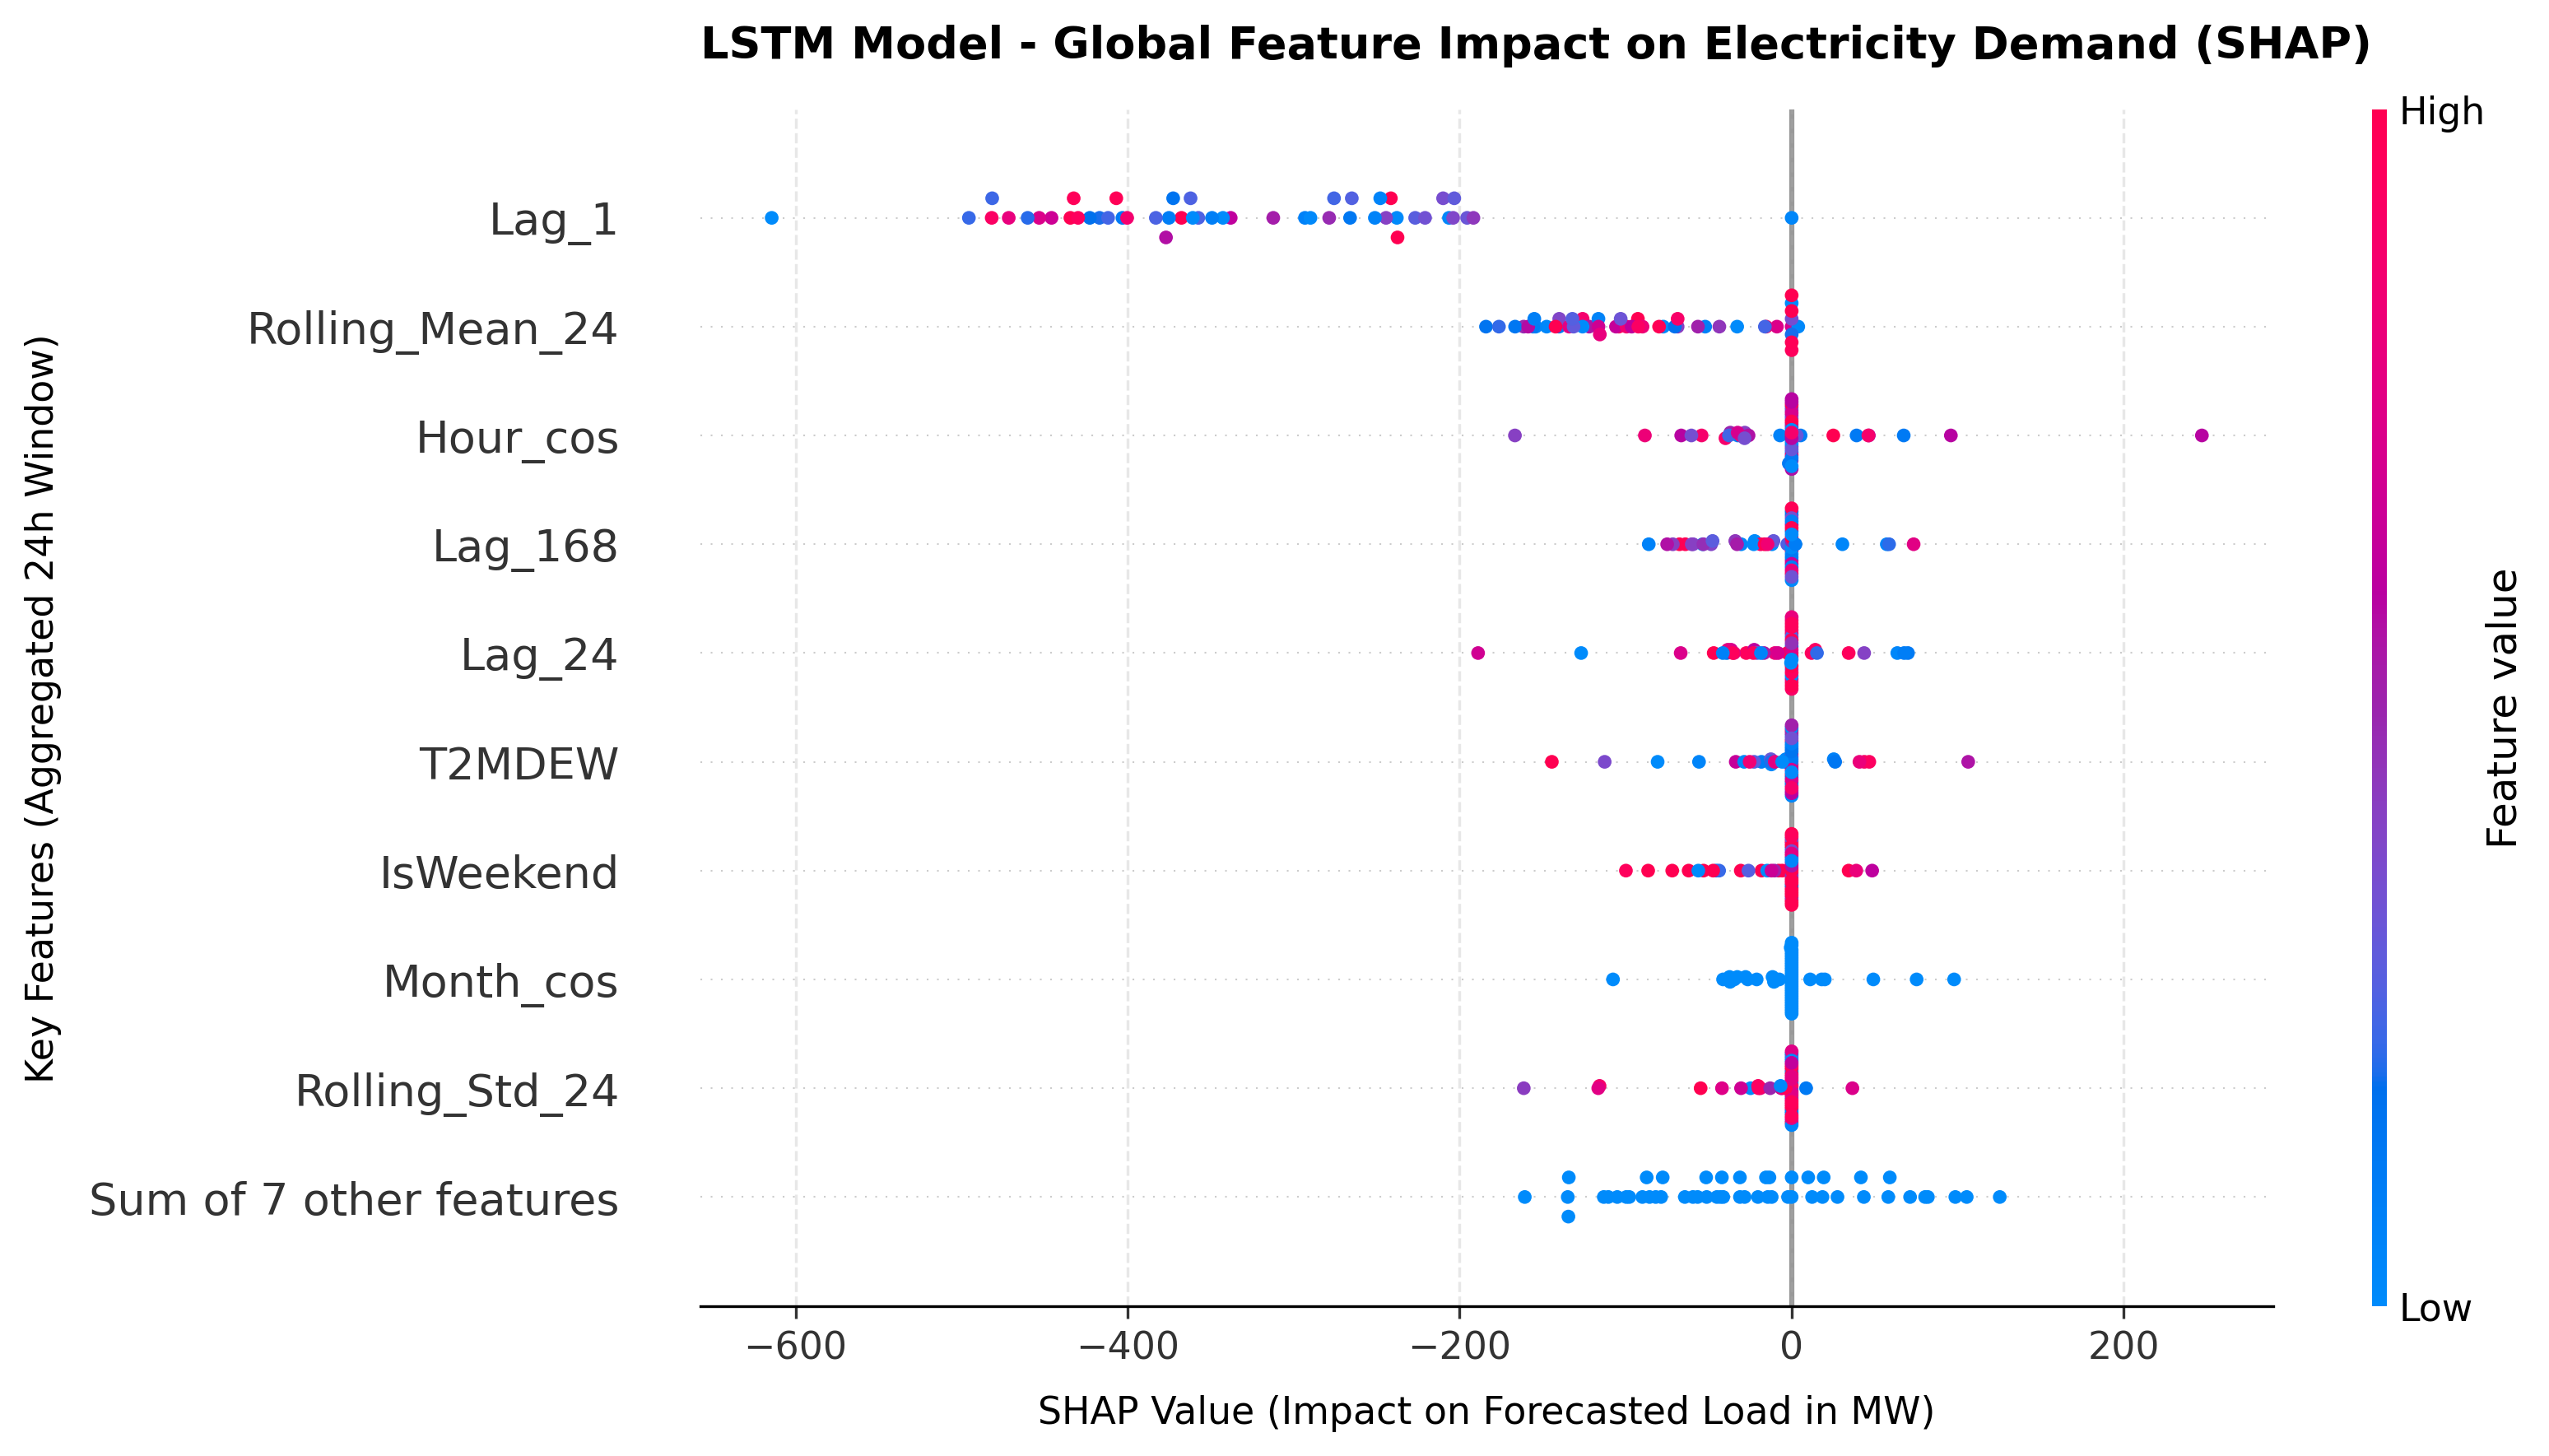

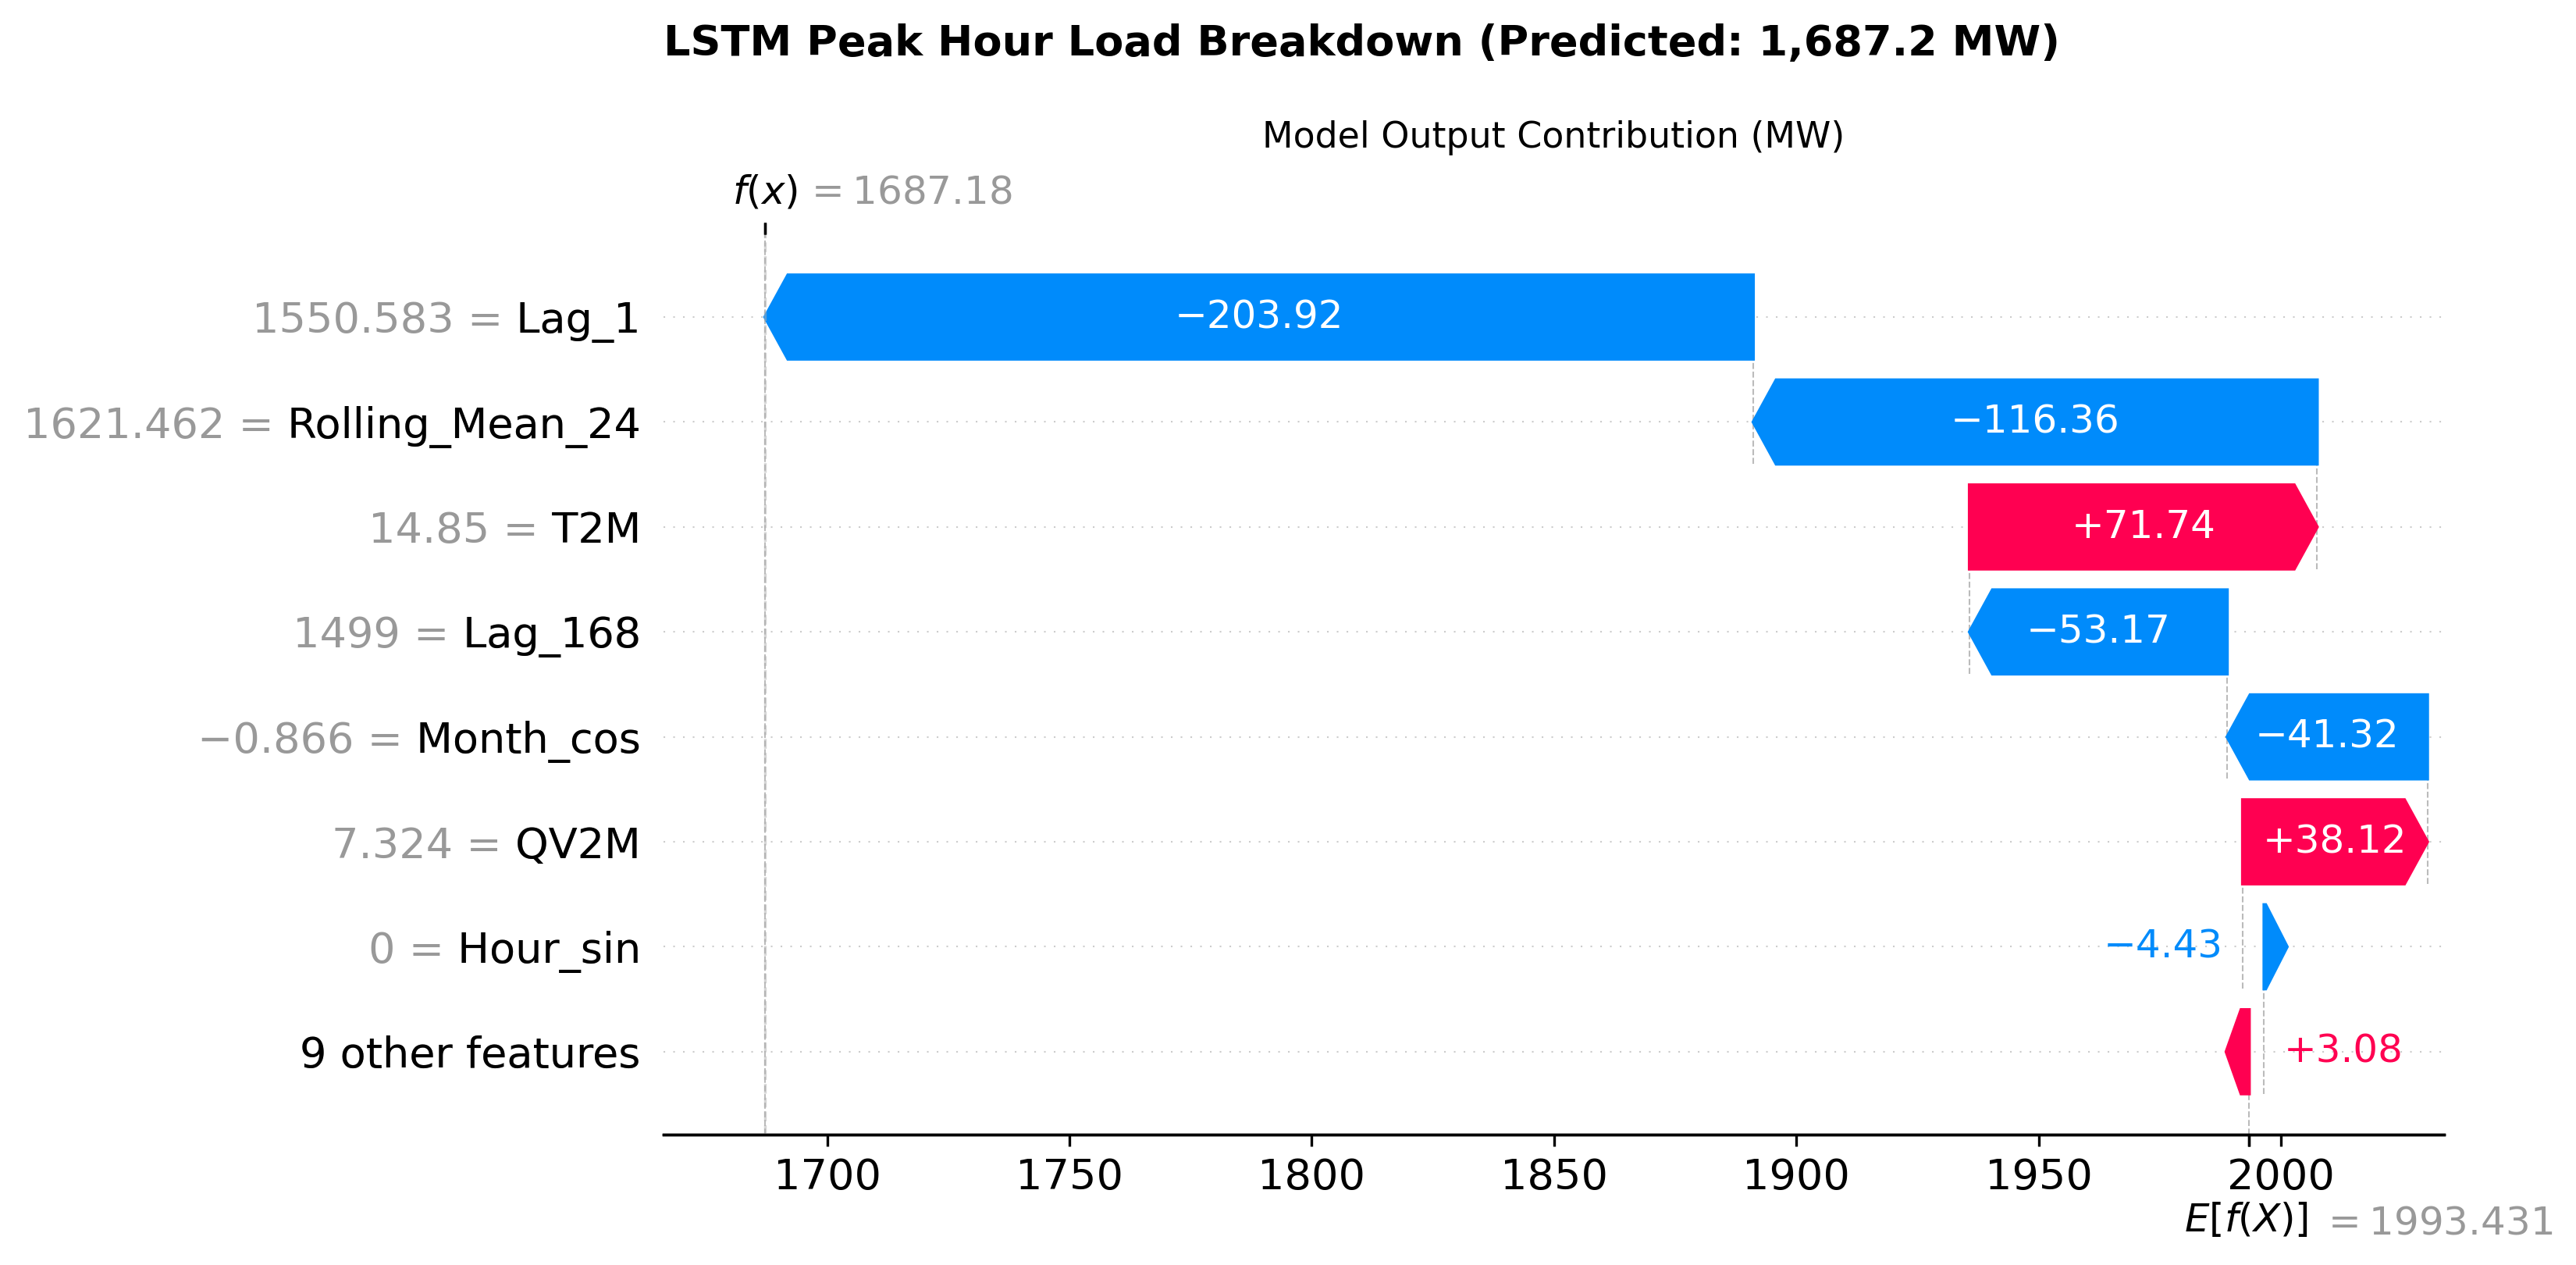

In [45]:
# ==============================================================================
# 3. AGGREGATE SHAP VALUES ACROSS TIME STEPS
# ==============================================================================
# Ensure shap_values is a numpy array (KernelExplainer can return a list)
shap_values_np = np.array(shap_values_flat[0] if isinstance(shap_values_flat, list) else shap_values_flat)

# Reshape SHAP values to (N, SEQ_LEN, num_features)
shap_values_3d = shap_values_np.reshape(test_sample_eval.shape[0], SEQ_LEN, X_train.shape[1])

# Sum SHAP contributions across all 24 lookback steps for total feature impact
shap_values_feature_level = np.sum(shap_values_3d, axis=1)

# Average test feature representation across sequence window for display
mean_test_features = np.mean(
    scaler_X.inverse_transform(test_sample_eval.reshape(-1, X_train.shape[1]))
    .reshape(test_sample_eval.shape[0], SEQ_LEN, -1),
    axis=1
)

# Extract expected base value (mean baseline prediction in MW)
expected_base_val = float(np.ravel(lstm_explainer.expected_value)[0])

# Construct Explanation object
shap_explanation_lstm = shap.Explanation(
    values=shap_values_feature_level,
    base_values=np.array([expected_base_val] * test_sample_eval.shape[0]),
    data=mean_test_features,
    feature_names=list(X.columns)
)

# ==============================================================================
# 4. VISUALIZE LSTM GLOBAL SHAP BEESWARM PLOT
# ==============================================================================
plt.close('all')
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

# Pass plot_size=None so SHAP draws directly onto the active subplots axis
shap.plots.beeswarm(
    shap_explanation_lstm,
    max_display=10,
    show=False,
    plot_size=None
)

plt.title(
    "LSTM Model - Global Feature Impact on Electricity Demand (SHAP)",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
plt.xlabel("SHAP Value (Impact on Forecasted Load in MW)", fontsize=11, labelpad=8)
plt.ylabel("Key Features (Aggregated 24h Window)", fontsize=11, labelpad=8)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. VISUALIZE LOCAL WATERFALL EXPLANATION FOR PEAK LOAD
# ==============================================================================
plt.close('all')

peak_lstm_idx = int(np.argmax(y_pred_lstm[:50]))
peak_lstm_pred = y_pred_lstm[peak_lstm_idx]

# Call waterfall directly without plt.subplots() to prevent blank duplicate canvases
shap.plots.waterfall(
    shap_explanation_lstm[peak_lstm_idx],
    max_display=8,
    show=False
)

plt.gcf().set_size_inches(11, 5.5)
plt.gcf().set_dpi(300)
plt.title(
    f"LSTM Peak Hour Load Breakdown (Predicted: {peak_lstm_pred:,.1f} MW)",
    fontsize=13,
    fontweight="bold",
    pad=20,
    loc="left",
)
plt.xlabel("Model Output Contribution (MW)", fontsize=11, labelpad=8)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()